<a href="https://colab.research.google.com/github/vedanthcr27/ML/blob/main/MLlab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   year  per capita income (US$)
0  1970              3399.299037
1  1971              3768.297935
2  1972              4251.175484
3  1973              4804.463248
4  1974              5576.514583
year                       0
per capita income (US$)    0
dtype: int64

Predicted Per Capita Income for Canada in 2020: $ 41288.69409441762


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


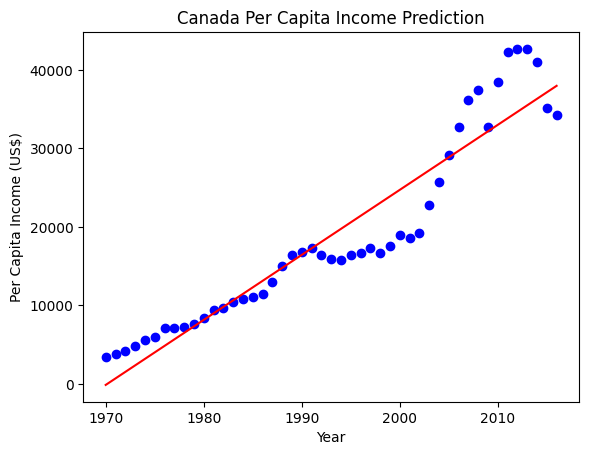

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("canada_per_capita_income.csv")

# Display first few rows
print(data.head())

# Check for missing values
print(data.isnull().sum())

# Define independent (X) and dependent (y) variables
X = data[['year']]
y = data['per capita income (US$)']

# Create Linear Regression model
model = LinearRegression()

# Train model
model.fit(X, y)

# Predict per capita income for year 2020
year_2020 = np.array([[2020]])
predicted_income = model.predict(year_2020)

print("\nPredicted Per Capita Income for Canada in 2020: $", predicted_income[0])

# Optional: Plot regression line
plt.scatter(X, y, color='blue')
plt.plot(X, model.predict(X), color='red')
plt.xlabel("Year")
plt.ylabel("Per Capita Income (US$)")
plt.title("Canada Per Capita Income Prediction")
plt.show()

   YearsExperience  Salary
0              1.1   39343
1              1.3   46205
2              1.5   37731
3              2.0   43525
4              2.2   39891
YearsExperience    2
Salary             0
dtype: int64

Predicted Salary for 12 Years of Experience: $ 139049.6749539778


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


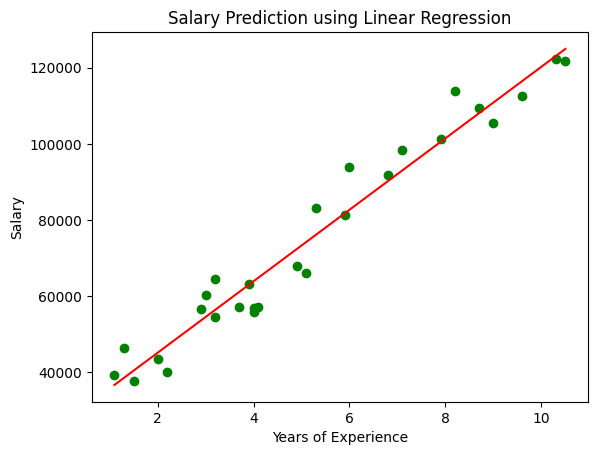

In [3]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("salary.csv")

# Display first few rows
print(data.head())

# Check for missing values
print(data.isnull().sum())

# 🔹 Handle missing values (DROP rows with NaN)
data = data.dropna()

# Define independent (X) and dependent (y) variables
X = data[['YearsExperience']]
y = data['Salary']

# Create Linear Regression model
model = LinearRegression()

# Train model
model.fit(X, y)

# Predict salary for 12 years of experience
experience_12 = np.array([[12]])
predicted_salary = model.predict(experience_12)

print("\nPredicted Salary for 12 Years of Experience: $", predicted_salary[0])

# Optional: Plot regression line
plt.scatter(X, y, color='green')
plt.plot(X, model.predict(X), color='red')
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary Prediction using Linear Regression")
plt.show()

In [6]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer

# Load dataset
data = pd.read_csv("hiring.csv")

print(data.head())
print(data.isnull().sum())

# 🔹 Step 1: Convert text experience to numbers
experience_mapping = {
    'zero': 0,
    'one': 1,
    'two': 2,
    'three': 3,
    'four': 4,
    'five': 5,
    'six': 6,
    'seven': 7,
    'eight': 8,
    'nine': 9,
    'ten': 10
}

data['experience'] = data['experience'].replace(experience_mapping)

# Convert to numeric
data['experience'] = pd.to_numeric(data['experience'], errors='coerce')

# 🔹 Step 2: Handle missing values
imputer = SimpleImputer(strategy='mean')

data[['experience', 'test_score(out of 10)']] = imputer.fit_transform(
    data[['experience', 'test_score(out of 10)']]
)

# 🔹 Step 3: Define X and y
X = data[['experience', 'test_score(out of 10)', 'interview_score(out of 10)']]
y = data['salary($)']

# 🔹 Step 4: Train model
model = LinearRegression()
model.fit(X, y)

# 🔹 Step 5: Predictions
candidate1 = model.predict([[2, 9, 6]])
candidate2 = model.predict([[12, 10, 10]])

print("\nPredicted Salary for (2 yr, 9 test, 6 interview): $", candidate1[0])
print("Predicted Salary for (12 yr, 10 test, 10 interview): $", candidate2[0])

  experience  test_score(out of 10)  interview_score(out of 10)  salary($)
0        NaN                    8.0                           9      50000
1        NaN                    8.0                           6      45000
2       five                    6.0                           7      60000
3        two                   10.0                          10      65000
4      seven                    9.0                           6      70000
experience                    2
test_score(out of 10)         1
interview_score(out of 10)    0
salary($)                     0
dtype: int64

Predicted Salary for (2 yr, 9 test, 6 interview): $ 49551.25846975038
Predicted Salary for (12 yr, 10 test, 10 interview): $ 85270.65233501681


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [7]:
# Import libraries
import pandas as pd
from sklearn.linear_model import LinearRegression

# Load dataset
data = pd.read_csv("1000_Companies.csv")

print(data.head())
print(data.isnull().sum())

# One Hot Encoding for 'State'
data = pd.get_dummies(data, columns=['State'], drop_first=True)

# Define independent and dependent variables
X = data.drop('Profit', axis=1)
y = data['Profit']

# Train Multiple Linear Regression model
model = LinearRegression()
model.fit(X, y)

# Create input for prediction
# NOTE: Adjust column order according to your dataset after encoding
input_data = pd.DataFrame({
    'R&D Spend': [91694.48],
    'Administration': [515841.3],
    'Marketing Spend': [11931.24],
    'State_Florida': [1],
    'State_New York': [0]  # depends on your dataset columns
})

# Predict profit
predicted_profit = model.predict(input_data)

print("\nPredicted Profit:", predicted_profit[0])

   R&D Spend  Administration  Marketing Spend       State     Profit
0  165349.20       136897.80        471784.10    New York  192261.83
1  162597.70       151377.59        443898.53  California  191792.06
2  153441.51       101145.55        407934.54     Florida  191050.39
3  144372.41       118671.85        383199.62    New York  182901.99
4  142107.34        91391.77        366168.42     Florida  166187.94
R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

Predicted Profit: 510570.9926108309
